In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

In [2]:
RAW_FILE_PATH = "fifa_fbref_merged.csv"

In [3]:
preview = pd.read_csv(RAW_FILE_PATH, nrows=5)
print("Total columns:", preview.shape[1])
preview.head()

Total columns: 135


,fifa_version,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age_fifa,height_cm,...,Per 90 Minutes_Performance_D,Per 90 Minutes_Performance_L,Per 90 Minutes_Performance_CS,Performance_CS%,Per 90 Minutes_Penalty Kicks_PKatt,Per 90 Minutes_Penalty Kicks_PKA,Per 90 Minutes_Penalty Kicks_PKsv,Per 90 Minutes_Penalty Kicks_PKm,Penalty Kicks_Save%,name_parts
0,24,K. Mbappe,Kylian Mbappe Lottin,"ST, LW",91,94,181500000.0,230000.0,24,182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'kylian', 'mbappe'}"
1,24,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,195,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'erling', 'haaland'}"
2,24,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'bruyne', 'de', 'kevin'}"
3,24,L. Messi,Lionel Andres Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'lionel', 'messi'}"
4,24,R. Lewandowski,Robert Lewandowski,ST,90,90,58000000.0,340000.0,34,185,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'robert', 'lewandowski'}"


In [4]:
columns_to_use = [
    'short_name', 'player_positions', 'pos', 'age_fifa', 'height_cm', 'weight_kg',
    'overall', 'potential', 'value_eur', 'wage_eur',
    'club_name', 'league_name', 'nationality_name', 'preferred_foot', 'season',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'Playing Time_Min', 'Playing Time_90s',
    'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A',
    'Per 90 Minutes_xG', 'Per 90 Minutes_xAG',
]

df = pd.read_csv(RAW_FILE_PATH, usecols=columns_to_use)
print("Shape:", df.shape)

memory_before_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f" memory usage before dtype opt : {memory_before_mb:,.1f} MB")
df.head()

Shape: (28436, 28)
 memory usage before dtype opt : 7.5 MB


,short_name,player_positions,overall,potential,value_eur,wage_eur,age_fifa,height_cm,weight_kg,club_name,...,physic,season,Playing Time_Min,Playing Time_90s,pos,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_xG,Per 90 Minutes_xAG
0,K. Mbappe,"ST, LW",91,94,181500000.0,230000.0,24,182,75,Paris Saint Germain,...,78,2324,2158.0,24.0,FW,1.13,0.29,1.42,0.87,0.24
1,E. Haaland,ST,91,94,185000000.0,340000.0,22,195,94,Manchester City,...,88,2324,2552.0,28.4,FW,0.95,0.18,1.13,1.03,0.15
2,K. De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,181,75,Manchester City,...,78,2324,1221.0,13.6,MF,0.29,0.74,1.03,0.18,0.85
3,L. Messi,"CF, CAM",90,90,41000000.0,23000.0,36,169,67,Inter Miami,...,64,2324,373.0,4.1,"FW,MF",0.24,0.48,0.72,0.63,0.33
4,R. Lewandowski,ST,90,90,58000000.0,340000.0,34,185,81,FC Barcelona,...,84,2324,2750.0,30.6,FW,0.62,0.26,0.88,0.59,0.16


In [5]:
df.isna().sum()

short_name               0
player_positions         0
overall                  0
potential                0
value_eur                0
wage_eur                 0
age_fifa                 0
height_cm                0
weight_kg                0
club_name                0
league_name              0
nationality_name         0
preferred_foot           0
pace                     0
shooting                 0
passing                  0
dribbling                0
defending                0
physic                   0
season                   0
Playing Time_Min         0
Playing Time_90s         0
pos                      2
Per 90 Minutes_Gls       0
Per 90 Minutes_Ast       0
Per 90 Minutes_G+A       0
Per 90 Minutes_xG     3930
Per 90 Minutes_xAG    3930
dtype: int64

In [6]:
rows_before_na = len(df)

df = df.dropna(subset=[
    'short_name', 'pos', 'overall', 'value_eur', 'wage_eur', 'Playing Time_Min',
])

rows_after_na = len(df)
print(f"before : {rows_before_na:,}  |  after : {rows_after_na:,}  |  removed : {rows_before_na - rows_after_na:,}")

before : 28,436  |  after : 28,434  |  removed : 2


In [7]:
rows_before = len(df)

MIN_MINUTES = 900

df = df[df['Playing Time_Min'] >= MIN_MINUTES]
df = df[(df['value_eur'] > 0) & (df['wage_eur'] > 0)]
df = df[df['overall'].between(1, 99)]

rows_after = len(df)
print(f" before: {rows_before:,}  |  after: {rows_after:,}  |  removed: {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before:.1%})")

 before: 28,434  |  after: 20,692  |  removed: 7,742 (27.2%)


In [8]:
dtype_map = {
    'age_fifa': 'int8', 'height_cm': 'int16', 'weight_kg': 'int16',
    'overall': 'int8', 'potential': 'int8',
    'value_eur': 'float32', 'wage_eur': 'float32',
    'league_name': 'category', 'nationality_name': 'category',
    'preferred_foot': 'category', 'pos': 'category',
    'pace': 'float32', 'shooting': 'float32', 'passing': 'float32',
    'dribbling': 'float32', 'defending': 'float32', 'physic': 'float32',
    'Playing Time_Min': 'float32', 'Playing Time_90s': 'float32',
    'Per 90 Minutes_Gls': 'float32', 'Per 90 Minutes_Ast': 'float32',
    'Per 90 Minutes_G+A': 'float32', 'Per 90 Minutes_xG': 'float32',
    'Per 90 Minutes_xAG': 'float32',
}

for col, new_type in dtype_map.items():
    df[col] = df[col].astype(new_type)

memory_after_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f" memory usage before opt : {memory_before_mb:,.1f} MB")
print(f" memory usage after opt : {memory_after_mb:,.1f} MB")
print(f" memory usage reduction : {(1 - memory_after_mb / memory_before_mb):.1%}")

df.info(memory_usage='deep')

 memory usage before opt : 7.5 MB
 memory usage after opt : 2.7 MB
 memory usage reduction : 63.5%
<class 'pandas.DataFrame'>
Index: 20692 entries, 0 to 28431
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   short_name          20692 non-null  str     
 1   player_positions    20692 non-null  str     
 2   overall             20692 non-null  int8    
 3   potential           20692 non-null  int8    
 4   value_eur           20692 non-null  float32 
 5   wage_eur            20692 non-null  float32 
 6   age_fifa            20692 non-null  int8    
 7   height_cm           20692 non-null  int16   
 8   weight_kg           20692 non-null  int16   
 9   club_name           20692 non-null  str     
 10  league_name         20692 non-null  category
 11  nationality_name    20692 non-null  category
 12  preferred_foot      20692 non-null  category
 13  pace                20692 non-null  float32 
 14  sho

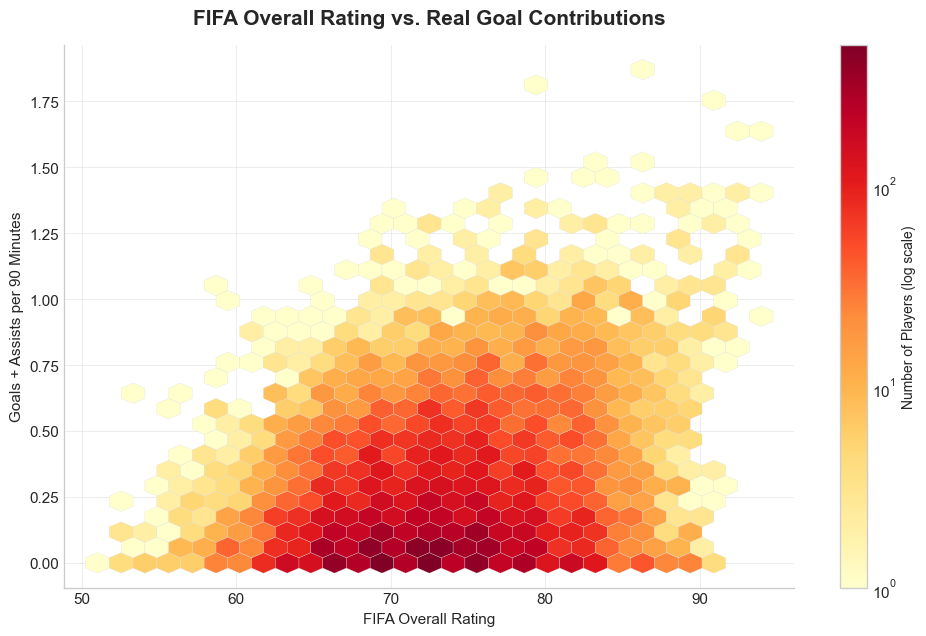

Correlation coefficient: 0.22


In [9]:
# تحلیل رابطه رتبه فیفا با عملکرد واقعی

fig, ax = plt.subplots(figsize=(10, 6.5), facecolor='white')

hb = ax.hexbin(df['overall'], df['Per 90 Minutes_G+A'], gridsize=28,
                cmap='YlOrRd', mincnt=1, bins='log', edgecolors='#dddddd', linewidths=0.2)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Number of Players (log scale)', fontsize=10)

ax.set_title('FIFA Overall Rating vs. Real Goal Contributions', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('FIFA Overall Rating', fontsize=11)
ax.set_ylabel('Goals + Assists per 90 Minutes', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

correlation = df['overall'].corr(df['Per 90 Minutes_G+A'])
print(f"Correlation coefficient: {correlation:.2f}")

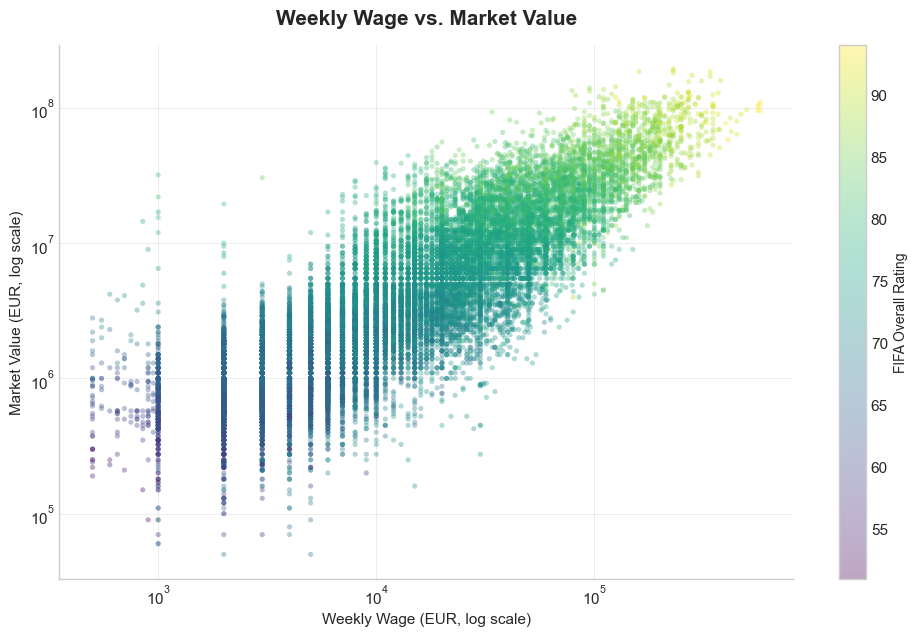

In [10]:
# تحلیل رابطه دستمزد هفتگی و ارزش بازار

fig, ax = plt.subplots(figsize=(10, 6.5), facecolor='white')

scatter = ax.scatter(df['wage_eur'], df['value_eur'],
                      c=df['overall'], cmap='viridis', alpha=0.35, s=14,
                      edgecolors='none')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Weekly Wage vs. Market Value', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Weekly Wage (EUR, log scale)', fontsize=11)
ax.set_ylabel('Market Value (EUR, log scale)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cb = fig.colorbar(scatter, ax=ax)
cb.set_label('FIFA Overall Rating', fontsize=10)

plt.tight_layout()
plt.show()

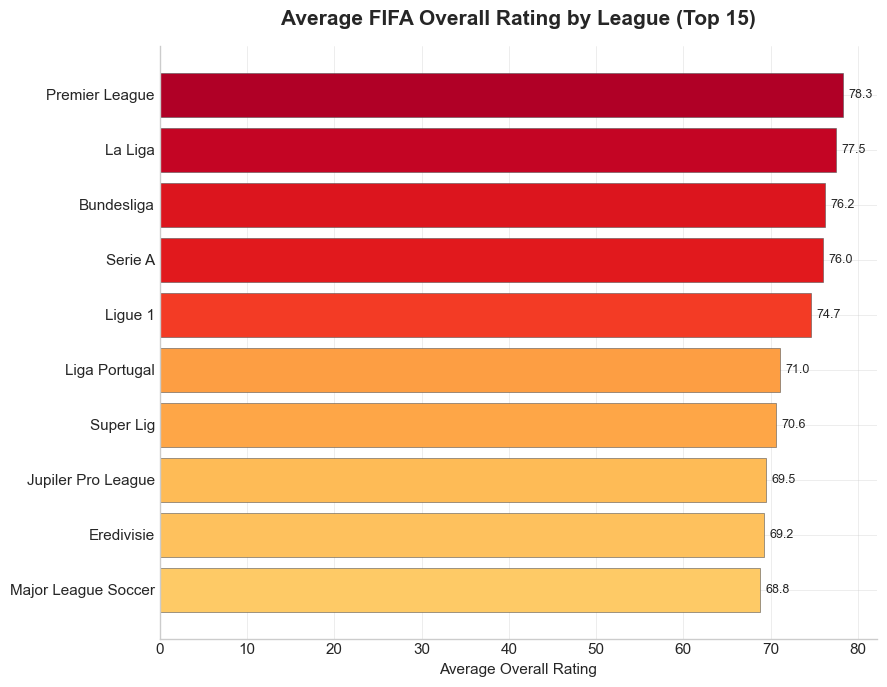

In [11]:
# تحلیل میانگین رتبه فیفا بازیکنان بر اساس لیگ

top_leagues = df['league_name'].value_counts().head(15).index
league_avg = df[df['league_name'].isin(top_leagues)].groupby('league_name', observed=True)['overall'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')

norm_values = (league_avg.values - league_avg.min()) / (league_avg.max() - league_avg.min())
bars = ax.barh(league_avg.index.astype(str), league_avg.values,
                color=plt.cm.YlOrRd(0.3 + 0.6 * norm_values), edgecolor='#555555', linewidth=0.4)

for bar, value in zip(bars, league_avg.values):
    ax.annotate(f'{value:.1f}', xy=(value, bar.get_y() + bar.get_height() / 2),
                xytext=(4, 0), textcoords='offset points', va='center', fontsize=9)

ax.set_title('Average FIFA Overall Rating by League (Top 15)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Average Overall Rating', fontsize=11)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

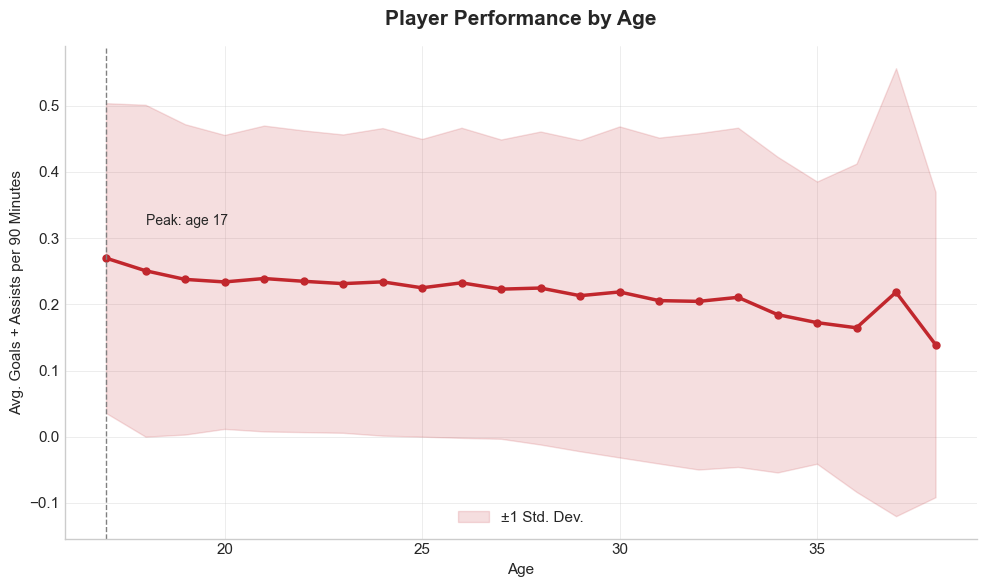

In [12]:
# تحلیل رابطه سن با عملکرد واقعی بازیکن

age_stats = df.groupby('age_fifa')['Per 90 Minutes_G+A'].agg(['mean', 'std', 'count'])
age_stats = age_stats[age_stats['count'] >= 20]

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

ax.plot(age_stats.index, age_stats['mean'], color='#C1272D', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(age_stats.index,
                 age_stats['mean'] - age_stats['std'],
                 age_stats['mean'] + age_stats['std'],
                 color='#C1272D', alpha=0.15, label='±1 Std. Dev.')

peak_age = age_stats['mean'].idxmax()
ax.axvline(peak_age, color='gray', linestyle='--', linewidth=1)
ax.annotate(f'Peak: age {peak_age}', xy=(peak_age, age_stats['mean'].max()),
            xytext=(peak_age + 1, age_stats['mean'].max() + 0.05), fontsize=10)

ax.set_title('Player Performance by Age', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Avg. Goals + Assists per 90 Minutes', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()